In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib
import keras
import tensorflow as tf

In [2]:
dataset= pd.read_csv('binarized_GCD', sep=',')
dataset= dataset.drop('Unnamed: 0', axis=1)
dataset

,A,G,J,H,S,B,C,D,P,M,Risk
0,1,1,1,1,0,0,0,0,0,1,1
1,0,0,1,1,1,0,1,1,0,0,0
2,1,1,0,1,1,1,0,0,0,1,1
3,1,1,1,0,1,0,1,1,0,1,1
4,1,1,1,0,1,0,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,1,1,1,0,0,0,0,1
996,1,1,0,1,1,0,1,1,1,0,1
997,1,1,1,1,1,1,0,0,0,1,1
998,0,1,1,0,1,0,0,1,0,1,0


In [3]:
import sklearn.metrics

import sklearn.model_selection

def train (X_train, Y_train, name_model):
    
    inputs = keras.Input(shape=X_train.shape[1])
    
    hidden_layer_1 = keras.layers.Dense(10, activation="relu")(inputs)
    
    output_layer = keras.layers.Dense(1, activation="relu")(hidden_layer_1)

    model = keras.Model(inputs=inputs, outputs=output_layer)
    
    model.compile(optimizer='adam', loss=keras.losses.binary_crossentropy, metrics=['accuracy'])

    print(model.summary())
    # train the model
    history= model.fit(X_train, Y_train, epochs=1000,verbose=False)
    
    model.save("./"+name_model)

    
    return history,model
    
    
def trainer(X_Raw, Y_Raw, model_name):
    
    x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(X_Raw, Y_Raw, test_size=0.2, random_state=5)
    
    lc,model= train (x_train, y_train, model_name)
    
    return lc, model

In [4]:
X_train=dataset.drop('Risk', axis=1).values
Y_train=dataset['Risk'].values

In [5]:
learning_curve, model= trainer(X_train,Y_train , 'GCD_NN')

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 10)]              0         
                                                                 
 dense (Dense)               (None, 10)                110       
                                                                 
 dense_1 (Dense)             (None, 1)                 11        
                                                                 
Total params: 121
Trainable params: 121
Non-trainable params: 0
_________________________________________________________________
None
INFO:tensorflow:Assets written to: ./GCD_NN\assets


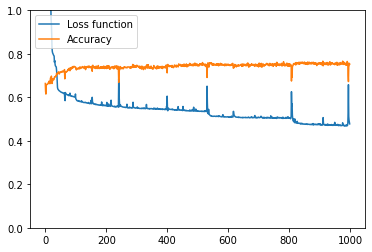

In [6]:
plt.plot(learning_curve.epoch,learning_curve.history['loss'], label= "Loss function")
plt.plot(learning_curve.epoch,learning_curve.history['accuracy'], label= "Accuracy")
plt.legend(loc="upper left")
plt.ylim(0, 1)
plt.show()